# Numerical Review of Price Distributions


In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from util import FixedOrderFormatter

# Load the data
base_dir = Path.cwd().parent.parent
data_path = base_dir / "data" / "processed" 

df = pd.read_csv(data_path / "combined_listings.csv")
#df = pd.read_csv(data_path / "combined_sold.csv")

print(df.columns.tolist())

/var/folders/dc/245wkwwd22jf9mtnyn_s6_pr0000gn/T/ipykernel_84283/1847605673.py:12: DtypeWarning: Columns (0: FireplaceYN, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path / "combined_listings.csv")


['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'Longitude.1', 'ElementarySchoolDistrict', 'CoB

## Original List Price Distribution

In [176]:
listingPrice = df['OriginalListPrice'].dropna()
min_price, max_price = listingPrice.min(), listingPrice.max()

ub = listingPrice.quantile(0.99)  # 99th percentile

t99 = listingPrice[(listingPrice <= ub)] # Lower 99% of the data
t1 = listingPrice[(listingPrice > ub)] # Upper 1% of the data

print(f"Minimum Listing Price: {min_price}")
print(f"Maximum Listing Price: {max_price}")
print(f"99th Percentile: {ub}")

Minimum Listing Price: 0.0
Maximum Listing Price: 1390000000.0
99th Percentile: 8500000.0


Text(0.5, 1.0, 'Above $100M')

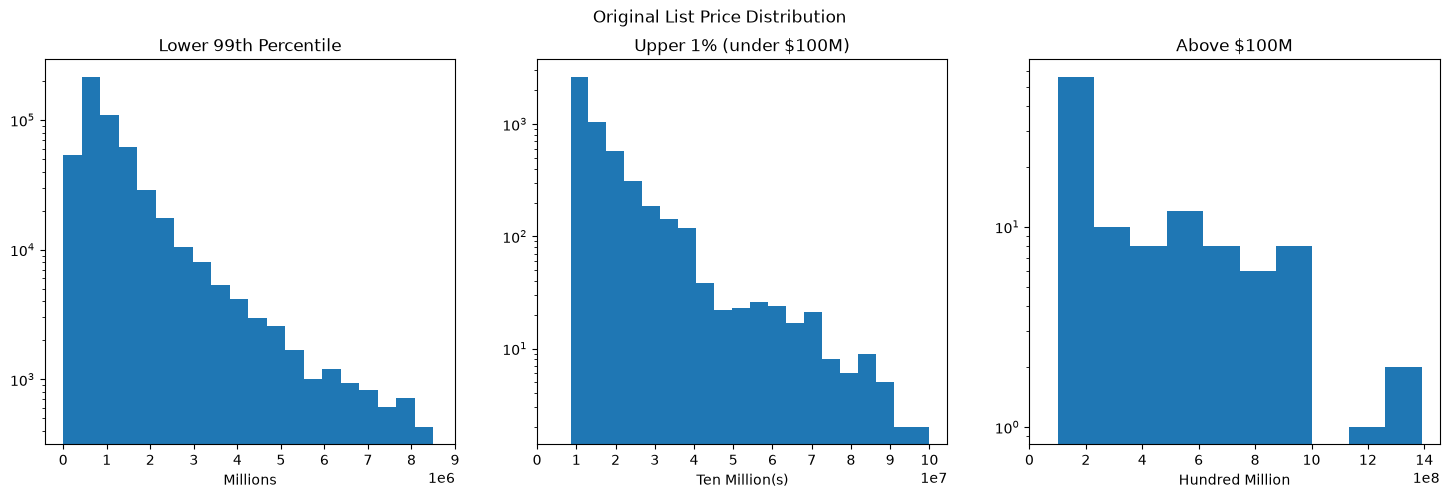

In [177]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Original List Price Distribution")

lower99 = t99                         # Lower 99th percentile
upper1_under100 = t1[(t1 < 100000000)]   # Upper 1%, under $100M
above100 = t1[(t1 >= 100000000)]         # Anything above $100M

ax1.hist(lower99, bins=20)
ax1.set(xlabel="Millions")
ax1.set(yscale='log')
ax1.set_xticks(np.linspace(0,9000000, 10))
ax1.set_title("Lower 99th Percentile")

ax2.hist(upper1_under100, bins=20)
ax2.set(xlabel="Ten Million(s)")
ax2.set(yscale='log')
ax2.set_xticks(np.linspace(0, 100000000, 11))
ax2.xaxis.set_major_formatter(FixedOrderFormatter(7))
ax2.set_title("Upper 1% (under $100M)")

ax3.hist(above100, bins=10)
ax3.set(xlabel="Hundred Million")
ax3.set(yscale='log')
ax3.set_xticks(np.linspace(0, 1400000000, 8))
ax3.xaxis.set_major_formatter(FixedOrderFormatter(8))
ax3.set_title("Above $100M")

## List Price Distribution

Text(0.5, 1.0, 'Above $100M')

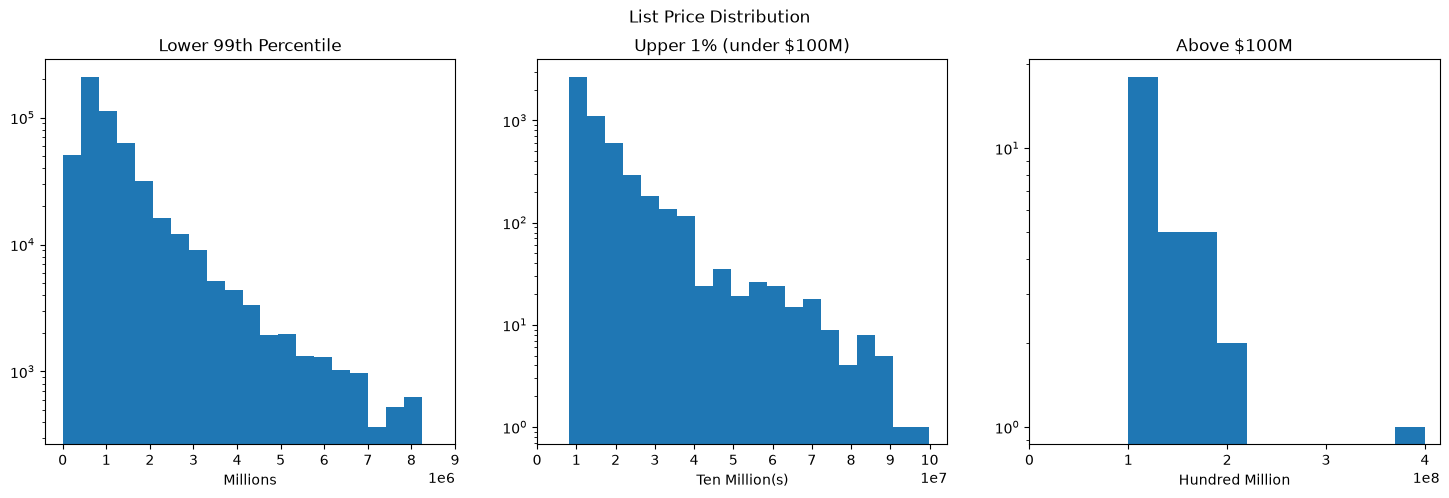

In [178]:
listPrice = df['ListPrice'].dropna()

ub = listPrice.quantile(0.99)  # 99th percentile

lp99 = listPrice[(listPrice <= ub)] # Lower 99% of the data
lp1 = listPrice[(listPrice > ub)] # Upper 1% of the data

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("List Price Distribution")

lower99 = lp99                          # Lower 99th percentile
upper1_under100 = lp1[(lp1 < 100000000)]   # Upper 1%, under $100M
above100 = lp1[(lp1 >= 100000000)]         # Anything above $100M

ax1.hist(lower99, bins=20)
ax1.set(xlabel="Millions")
ax1.set(yscale='log')
ax1.set_xticks(np.linspace(0, 9000000, 10))
ax1.set_title("Lower 99th Percentile")

ax2.hist(upper1_under100, bins=20)
ax2.set(xlabel="Ten Million(s)")
ax2.set(yscale='log')
ax2.set_xticks(np.linspace(0, 100000000, 11))
ax2.xaxis.set_major_formatter(FixedOrderFormatter(7))
ax2.set_title("Upper 1% (under $100M)")

ax3.hist(above100, bins=10)
ax3.set(xlabel="Hundred Million")
ax3.set(yscale='log')
ax3.set_xticks(np.linspace(0, 400000000, 5))
ax3.xaxis.set_major_formatter(FixedOrderFormatter(8))
ax3.set_title("Above $100M")

## Close Price Distribution

Text(0.5, 1.0, 'Above $100M')

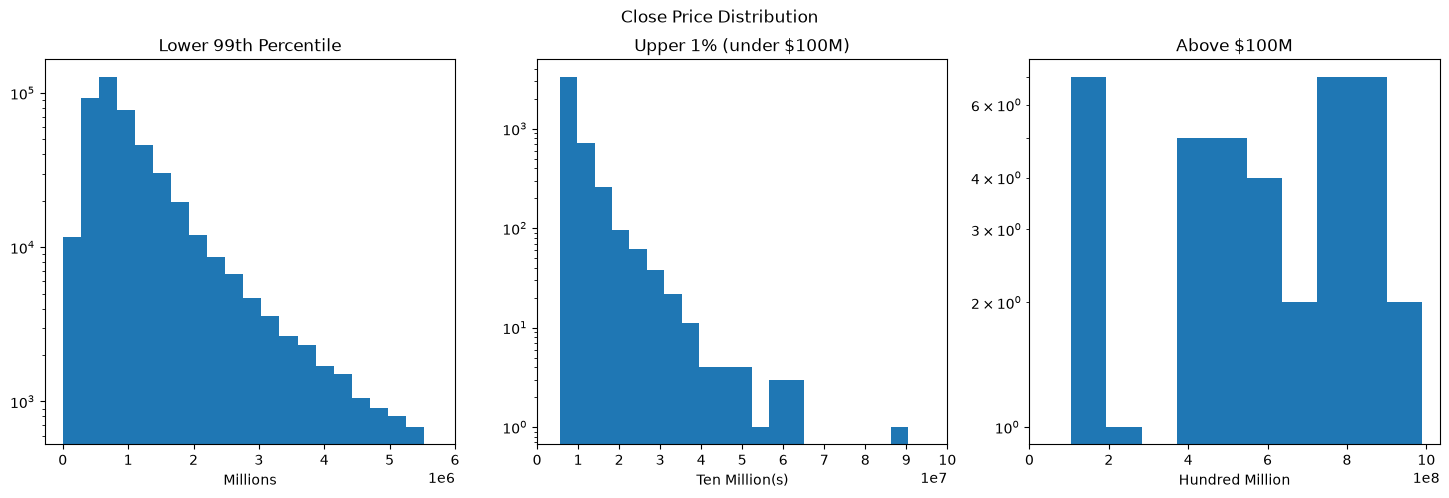

In [179]:
sold = pd.read_csv(data_path / "combined_sold.csv", low_memory=False)
closePrice = sold['ClosePrice'].dropna()

ub = closePrice.quantile(0.99)  # 99th percentile

cp99 = closePrice[(closePrice <= ub)] # Lower 99% of the data
cp1 = closePrice[(closePrice > ub)] # Upper 1% of the data

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Close Price Distribution")

lower99 = cp99                          # Lower 99th percentile
upper1_under100 = cp1[(cp1 < 100000000)]   # Upper 1%, under $100M
above100 = cp1[(cp1 >= 100000000)]         # Anything above $100M

ax1.hist(lower99, bins=20)
ax1.set(xlabel="Millions")
ax1.set(yscale='log')
ax1.set_xticks(np.linspace(0, 6000000, 7))
ax1.set_title("Lower 99th Percentile")

ax2.hist(upper1_under100, bins=20)
ax2.set(xlabel="Ten Million(s)")
ax2.set(yscale='log')
ax2.set_xticks(np.linspace(0, 100000000, 11))
ax2.xaxis.set_major_formatter(FixedOrderFormatter(7))
ax2.set_title("Upper 1% (under $100M)")

ax3.hist(above100, bins=10)
ax3.set(xlabel="Hundred Million")
ax3.set(yscale='log')
ax3.set_xticks(np.linspace(0, 1000000000, 6))
ax3.xaxis.set_major_formatter(FixedOrderFormatter(8))
ax3.set_title("Above $100M")

## Price Percentiles

In [180]:
prices = {
    "OriginalListPrice": df['OriginalListPrice'].dropna(),
    "ListPrice": df['ListPrice'].dropna(),
    "ClosePrice": sold['ClosePrice'].dropna(),
}

pct = [0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 0.999]
percentiles = pd.DataFrame({name: s.describe(percentiles=pct) for name, s in prices.items()})
percentiles.round(0)

,OriginalListPrice,ListPrice,ClosePrice
count,5.322920e+05,533052.0,458334.0
mean,1.404915e+06,1321242.0,1186149.0
std,7.379022e+06,2419769.0,5989704.0
min,0.000000e+00,100.0,0.0
1%,2.000000e+05,214000.0,202000.0
5%,3.490000e+05,348000.0,339900.0
25%,5.880000e+05,585000.0,575000.0
50%,8.490000e+05,849000.0,820000.0
75%,1.395000e+06,1389000.0,1300000.0
90%,2.390000e+06,2350000.0,2060000.0


## Price Boxplots

Text(0.5, 1.0, 'Price Distributions (whiskers = 1st-99th pct)')

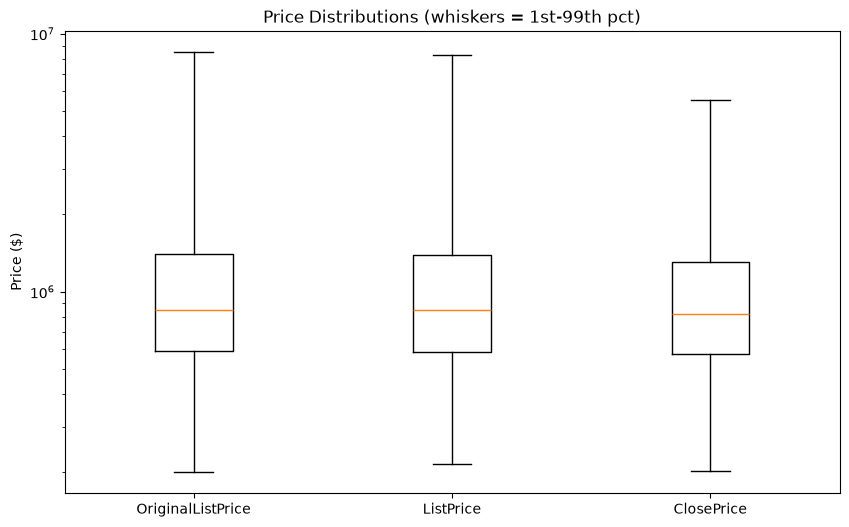

In [181]:
prices = {
    "OriginalListPrice": df['OriginalListPrice'].dropna(),
    "ListPrice": df['ListPrice'].dropna(),
    "ClosePrice": sold['ClosePrice'].dropna(),
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([s[s > 0] for s in prices.values()], tick_labels=list(prices), showfliers=False, whis=(1, 99))
ax.set(yscale='log')
ax.set_ylabel("Price ($)")
ax.set_title("Price Distributions (whiskers = 1st-99th pct)")